In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
zip_path = '/content/drive/MyDrive/final_dataset.zip'
extract_path = '/content/final_dataset'

!unzip -q "$zip_path" -d "$extract_path"

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import os

# Paths to your dataset folders
train_dir = "/content/final_dataset/train"
val_dir = "/content/final_dataset/val"
test_dir = "/content/final_dataset/test"

# Parameters
img_size = (224,224)
batch_size = 32
num_classes = 41  # change if needed

# Load datasets using tf.data
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical",
    shuffle=True
)
class_names = train_ds.class_names

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical",
    shuffle=True
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical",
    shuffle=False
)

# Prefetch for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

# Data augmentation layer
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(factor=0.1)
])



Found 28700 files belonging to 41 classes.
Found 8200 files belonging to 41 classes.
Found 4100 files belonging to 41 classes.


In [ ]:
print(class_names)

['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Cotton___Bacterial_blight', 'Cotton___Curl_virus', 'Cotton___Fusarium_wilt', 'Cotton___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Rice___Bacterial_leaf_blight', 'Rice___Brown_spot', 'Rice___Leaf_blast', 'Rice___Leaf_scald', 'Rice___Sheath_blight', 'Rice___healthy', 'Sugarcane___Mosaic', 'Sugarcane___Red_rot', 'Sugarcane___Rust', 'Sugarcane___Yellow', 'Sugarcane___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites_Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yel

In [ ]:

class_indices = {i: name for i, name in enumerate(class_names)}
class_indices

{0: 'Apple___Apple_scab',
 1: 'Apple___Black_rot',
 2: 'Apple___Cedar_apple_rust',
 3: 'Apple___healthy',
 4: 'Corn_(maize)___Common_rust_',
 5: 'Corn_(maize)___Northern_Leaf_Blight',
 6: 'Corn_(maize)___healthy',
 7: 'Cotton___Bacterial_blight',
 8: 'Cotton___Curl_virus',
 9: 'Cotton___Fusarium_wilt',
 10: 'Cotton___healthy',
 11: 'Grape___Black_rot',
 12: 'Grape___Esca_(Black_Measles)',
 13: 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 14: 'Grape___healthy',
 15: 'Pepper,_bell___Bacterial_spot',
 16: 'Pepper,_bell___healthy',
 17: 'Potato___Early_blight',
 18: 'Potato___Late_blight',
 19: 'Potato___healthy',
 20: 'Rice___Bacterial_leaf_blight',
 21: 'Rice___Brown_spot',
 22: 'Rice___Leaf_blast',
 23: 'Rice___Leaf_scald',
 24: 'Rice___Sheath_blight',
 25: 'Rice___healthy',
 26: 'Sugarcane___Mosaic',
 27: 'Sugarcane___Red_rot',
 28: 'Sugarcane___Rust',
 29: 'Sugarcane___Yellow',
 30: 'Sugarcane___healthy',
 31: 'Tomato___Bacterial_spot',
 32: 'Tomato___Early_blight',
 33: 'Tomato___L

In [ ]:

import json
json.dump(class_indices, open('class_indices.json', 'w'))

In [ ]:
# Build the CNN model (5 blocks, global pooling)
model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(2),

    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(2),

    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.Conv2D(128, 3, activation='relu'),
    layers.MaxPooling2D(2),

    layers.Conv2D(256, 3, padding='same', activation='relu'),
    layers.Conv2D(256, 3, activation='relu'),
    layers.MaxPooling2D(2),

    layers.Conv2D(512, 3, padding='same', activation='relu'),
    layers.Conv2D(512, 3, activation='relu'),
    layers.MaxPooling2D(2),

    layers.Dropout(0.25),

    layers.GlobalAveragePooling2D(),

    layers.Dense(1500, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(num_classes, activation='softmax')
])


In [ ]:
optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001)
model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:


model.summary()



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 222, 222, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 111, 111, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 109, 109, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 54, 54, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 24, 24, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 12, 12, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 10, 10, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 5, 5, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 5, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1500)           │       769,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 41)             │        61,541 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,543,265 (21.15 MB)

 Trainable params: 5,543,265 (21.15 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

# Callbacks
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.3, patience=3, verbose=1)
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_model.keras", monitor='val_loss', save_best_only=True)

In [ ]:
# Train
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 1/20
897/897 ━━━━━━━━━━━━━━━━━━━━ 219s 231ms/step - accuracy: 0.0770 - loss: 3.3370 - val_accuracy: 0.3277 - val_loss: 2.1357 - learning_rate: 1.0000e-04
Epoch 2/20
897/897 ━━━━━━━━━━━━━━━━━━━━ 260s 237ms/step - accuracy: 0.3452 - loss: 2.0815 - val_accuracy: 0.5421 - val_loss: 1.4417 - learning_rate: 1.0000e-04
Epoch 3/20
897/897 ━━━━━━━━━━━━━━━━━━━━ 214s 238ms/step - accuracy: 0.5178 - loss: 1.4809 - val_accuracy: 0.5590 - val_loss: 1.3512 - learning_rate: 1.0000e-04
Epoch 4/20
897/897 ━━━━━━━━━━━━━━━━━━━━ 208s 231ms/step - accuracy: 0.6213 - loss: 1.1369 - val_accuracy: 0.7121 - val_loss: 0.8816 - learning_rate: 1.0000e-04
Epoch 5/20
897/897 ━━━━━━━━━━━━━━━━━━━━ 263s 233ms/step - accuracy: 0.6816 - loss: 0.9317 - val_accuracy: 0.7239 - val_loss: 0.7988 - learning_rate: 1.0000e-04
Epoch 6/20
897/897 ━━━━━━━━━━━━━━━━━━━━ 261s 232ms/step - accuracy: 0.7344 - loss: 0.7864 - val_accuracy: 0.7149 - val_loss: 0.8560 - learning_rate: 1.0000e-04
Epoch 7/20
897/897 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:

# Evaluate on test set
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Accuracy: {test_acc:.4f}")


129/129 ━━━━━━━━━━━━━━━━━━━━ 9s 73ms/step - accuracy: 0.9521 - loss: 0.1521
Test Accuracy: 0.9268


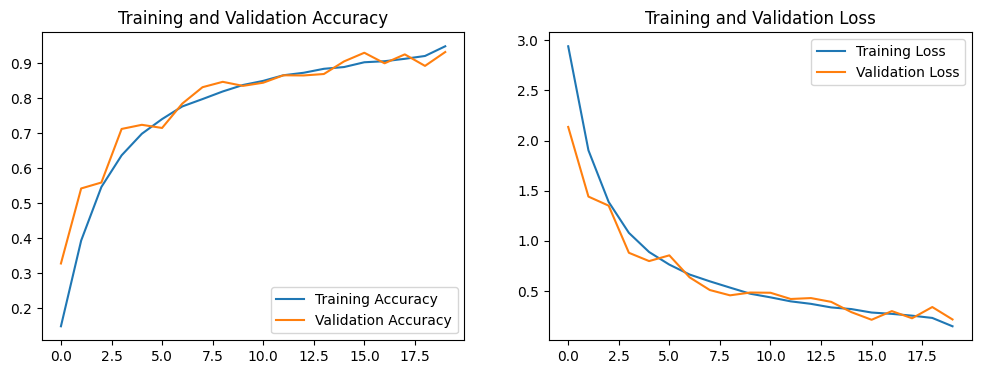

In [ ]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy and loss
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [ ]:
model.save("5blockcnn.keras")

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_true, axis=1)

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))


129/129 ━━━━━━━━━━━━━━━━━━━━ 9s 66ms/step
[[ 99   0   0 ...   0   0   0]
 [  0 100   0 ...   0   0   0]
 [  2   1  95 ...   0   0   0]
 ...
 [  0   0   0 ...  89   1   0]
 [  0   0   0 ...   0  99   0]
 [  0   0   0 ...   0   0  99]]
              precision    recall  f1-score   support

           0       0.88      0.99      0.93       100
           1       0.99      1.00      1.00       100
           2       1.00      0.95      0.97       100
           3       0.99      0.90      0.94       100
           4       0.98      0.94      0.96       100
           5       0.95      0.96      0.96       100
           6       0.99      0.95      0.97       100
           7       0.92      0.98      0.95       100
           8       0.96      0.95      0.95       100
           9       0.97      0.99      0.98       100
          10       0.99      0.97      0.98       100
          11       0.93      0.97      0.95       100
          12       0.99      0.99      0.99       100
         

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step


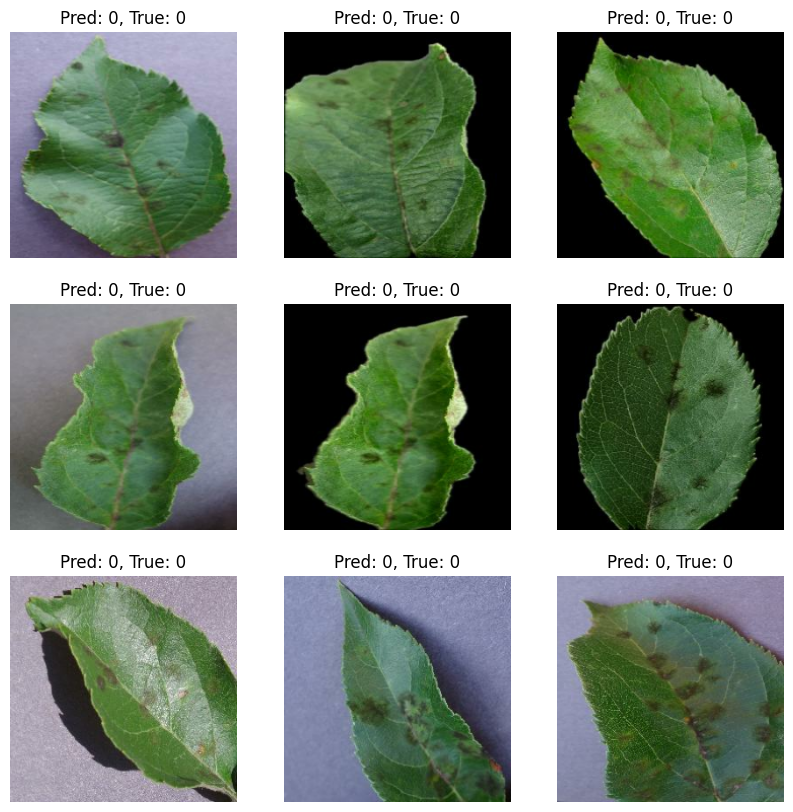

In [ ]:
import matplotlib.pyplot as plt

for images, labels in test_ds.take(1):
    preds = model.predict(images)
    pred_classes = np.argmax(preds, axis=1)
    true_classes = np.argmax(labels.numpy(), axis=1)

    plt.figure(figsize=(10, 10))
    for i in range(9):
        plt.subplot(3, 3, i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(f"Pred: {pred_classes[i]}, True: {true_classes[i]}")
        plt.axis("off")
    plt.show()


In [ ]:
# Train for 10 more epochs (adjust as needed)
history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,         # continue up to epoch 30
    initial_epoch=20,  # continue from epoch 20
    callbacks=[early_stop, reduce_lr, checkpoint]
)


Epoch 21/30
897/897 ━━━━━━━━━━━━━━━━━━━━ 208s 232ms/step - accuracy: 0.9318 - loss: 0.1998 - val_accuracy: 0.9180 - val_loss: 0.2566 - learning_rate: 3.0000e-05
Epoch 22/30
897/897 ━━━━━━━━━━━━━━━━━━━━ 208s 232ms/step - accuracy: 0.9403 - loss: 0.1762 - val_accuracy: 0.9122 - val_loss: 0.2720 - learning_rate: 3.0000e-05
Epoch 23/30
897/897 ━━━━━━━━━━━━━━━━━━━━ 268s 238ms/step - accuracy: 0.9422 - loss: 0.1676 - val_accuracy: 0.9068 - val_loss: 0.3076 - learning_rate: 3.0000e-05
Epoch 24/30
897/897 ━━━━━━━━━━━━━━━━━━━━ 262s 238ms/step - accuracy: 0.9472 - loss: 0.1527 - val_accuracy: 0.9309 - val_loss: 0.2307 - learning_rate: 3.0000e-05
Epoch 25/30
897/897 ━━━━━━━━━━━━━━━━━━━━ 214s 239ms/step - accuracy: 0.9501 - loss: 0.1466 - val_accuracy: 0.9187 - val_loss: 0.2733 - learning_rate: 3.0000e-05
Epoch 26/30
897/897 ━━━━━━━━━━━━━━━━━━━━ 262s 239ms/step - accuracy: 0.9507 - loss: 0.1458 - val_accuracy: 0.9373 - val_loss: 0.2028 - learning_rate: 3.0000e-05
Epoch 27/30
897/897 ━━━━━━━━━━━━━━

In [ ]:

# Evaluate on test set
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Accuracy: {test_acc:.4f}")


129/129 ━━━━━━━━━━━━━━━━━━━━ 8s 60ms/step - accuracy: 0.9640 - loss: 0.1352
Test Accuracy: 0.9444


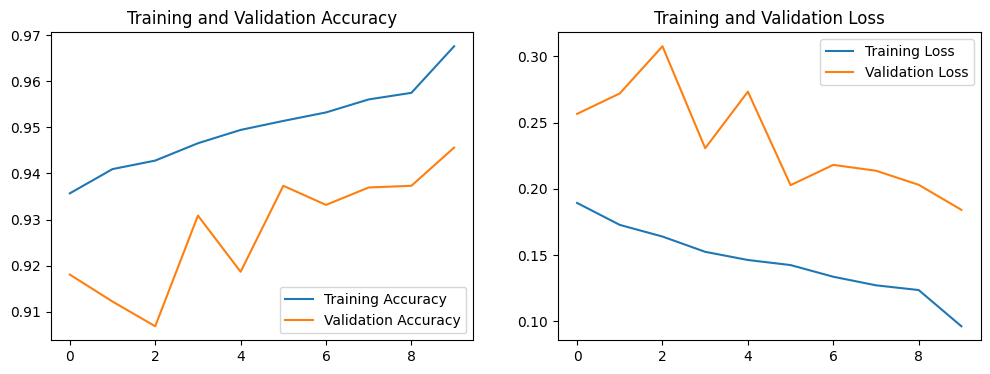

In [ ]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy and loss
acc = history_finetune.history['accuracy']
val_acc = history_finetune.history['val_accuracy']
loss = history_finetune.history['loss']
val_loss = history_finetune.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [ ]:
model.save("5BlockscnnBest.keras")

In [ ]:
test_loss, test_acc = model.evaluate(val_ds)
print(f"Test Accuracy: {test_acc:.4f}")

257/257 ━━━━━━━━━━━━━━━━━━━━ 15s 60ms/step - accuracy: 0.9495 - loss: 0.1792
Test Accuracy: 0.9456
